In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb
from prophet import Prophet
import warnings
warnings.filterwarnings('ignore')

# 1. Load Data
df = pd.read_csv('../data/processed/ae_features.csv', parse_dates=['WeekEndingDate'])
le = LabelEncoder()
df['BoardCode'] = le.fit_transform(df['HBT'])

# 2. Split Data
train_df = df[df['WeekEndingDate'] < '2023-01-01'].copy()
test_df  = df[df['WeekEndingDate'] >= '2023-01-01'].copy()

# Feature lists
feature_cols = [
    'BoardCode', 'SIMDScore', 'IsUrban', 'PopulationK',
    'WeekOfYear', 'Month', 'FluSeasonFlag', 'WinterFlag', 'ChristmasWeek',
    'CovidEra', 'PostCovidStress', 'CovidPhase', 'VaxRollout',
    'Lag1_BreachRate', 'Lag2_BreachRate', 'Lag4_BreachRate', 'Lag8_BreachRate',
    'Lag1_Attendances', 'Lag4_Attendances',
    'RollingMean4W', 'RollingMean8W', 'RollingStd4W', 'RollingMax4W',
    'BreachRateDelta', 'FluSearchIndex', 'IsSchoolHoliday', 'DaysToNextHoliday',
    'StaffingRatioPer1000', 'StaffingPressureFlag', 'AttendancesPer1000',
]

prophet_exog = [
    'CovidEra', 'PostCovidStress', 'FluSeasonFlag', 'WinterFlag',
    'IsSchoolHoliday', 'StaffingPressureFlag', 'FluSearchIndex'
]

# 3. Train Global XGBoost
print("Training XGBoost...")
model_xgb = xgb.XGBRegressor(
    n_estimators=500, learning_rate=0.05, max_depth=5,
    subsample=0.8, colsample_bytree=0.8, min_child_weight=5,
    reg_alpha=0.1, reg_lambda=1.0, random_state=42, n_jobs=-1,
    early_stopping_rounds=30, eval_metric='rmse'
)
model_xgb.fit(
    train_df.dropna(subset=feature_cols + ['BreachRate'])[feature_cols], 
    train_df.dropna(subset=feature_cols + ['BreachRate'])['BreachRate'],
    eval_set=[(test_df.dropna(subset=feature_cols + ['BreachRate'])[feature_cols], 
               test_df.dropna(subset=feature_cols + ['BreachRate'])['BreachRate'])],
    verbose=False
)

# 4. Train Prophet (Forth Valley Only to save time)
print("Training Prophet for Forth Valley...")
fv_train = train_df[train_df['BoardName'] == 'Forth Valley'].copy()
hol_dates = fv_train[fv_train['IsSchoolHoliday'] == 1]['WeekEndingDate']
all_holidays = pd.concat([
    pd.DataFrame({'ds': pd.to_datetime(hol_dates), 'holiday': 'ScottishSchoolHoliday'}),
    pd.DataFrame({'ds': [pd.Timestamp('2020-03-16'), pd.Timestamp('2022-04-01')],
                  'holiday': ['CovidLockdownStart', 'PostCovidPressureOnset'],
                  'lower_window': [0, 0], 'upper_window': [7, 30]})
], ignore_index=True)

prophet_df = fv_train[['WeekEndingDate', 'BreachRate'] + prophet_exog].copy()
prophet_df.columns = ['ds', 'y'] + prophet_exog
prophet_df['y'] = prophet_df['y'].clip(0.001, 0.999)
prophet_df['cap'], prophet_df['floor'] = 0.85, 0.0

m_prophet = Prophet(growth='logistic', yearly_seasonality=True, holidays=all_holidays, changepoint_prior_scale=0.05)
for col in prophet_exog: m_prophet.add_regressor(col)
m_prophet.fit(prophet_df)

print("Models ready ✓")

Training XGBoost...
Training Prophet for Forth Valley...


21:09:18 - cmdstanpy - INFO - Chain [1] start processing
21:09:18 - cmdstanpy - INFO - Chain [1] done processing


Models ready ✓


In [2]:
# Isolate Q1 2023 (Jan - Mar) for Forth Valley
scenario_mask = (test_df['BoardName'] == 'Forth Valley') & (test_df['WeekEndingDate'] <= '2023-03-31')
baseline_df = test_df[scenario_mask].copy()

# Create the Counterfactual (CF) DataFrame
cf_df = baseline_df.copy()

# SCENARIO: What if they had 10% more clinical WTE staff?
cf_df['StaffingRatioPer1000'] = cf_df['StaffingRatioPer1000'] * 1.10

# Recalculate the StaffingPressureFlag based on the new ratio
# (If the new ratio pushes them above the historical 10th percentile, the pressure flag turns off)
fv_10th_percentile = train_df[train_df['BoardName'] == 'Forth Valley']['StaffingRatioPer1000'].quantile(0.10)
cf_df['StaffingPressureFlag'] = (cf_df['StaffingRatioPer1000'] < fv_10th_percentile).astype(int)

print(f"Scenario Weeks: {len(baseline_df)}")
print("Average Staffing Ratio (Baseline): {:.2f}".format(baseline_df['StaffingRatioPer1000'].mean()))
print("Average Staffing Ratio (+10%):     {:.2f}".format(cf_df['StaffingRatioPer1000'].mean()))

Scenario Weeks: 13
Average Staffing Ratio (Baseline): 4738.46
Average Staffing Ratio (+10%):     5212.31


In [3]:
# Optimized weights from previous notebook
W_XGB = 0.983
W_PROPHET = 0.017

# 1. BASELINE PREDICTIONS
xgb_base = model_xgb.predict(baseline_df[feature_cols]).clip(0, 1)
prophet_base_input = baseline_df[['WeekEndingDate'] + prophet_exog].rename(columns={'WeekEndingDate': 'ds'})
prophet_base_input['cap'], prophet_base_input['floor'] = 0.85, 0.0
prophet_base = m_prophet.predict(prophet_base_input)['yhat'].clip(0, 1).values

baseline_df['Predicted_BreachRate'] = (W_XGB * xgb_base) + (W_PROPHET * prophet_base)

# 2. COUNTERFACTUAL PREDICTIONS
xgb_cf = model_xgb.predict(cf_df[feature_cols]).clip(0, 1)
prophet_cf_input = cf_df[['WeekEndingDate'] + prophet_exog].rename(columns={'WeekEndingDate': 'ds'})
prophet_cf_input['cap'], prophet_cf_input['floor'] = 0.85, 0.0
prophet_cf = m_prophet.predict(prophet_cf_input)['yhat'].clip(0, 1).values

cf_df['Predicted_BreachRate'] = (W_XGB * xgb_cf) + (W_PROPHET * prophet_cf)

# 3. CALCULATE BREACHES AVOIDED
# Breaches = Attendances * BreachRate
baseline_breaches = (baseline_df['Attendances'] * baseline_df['Predicted_BreachRate']).sum()
cf_breaches = (cf_df['Attendances'] * cf_df['Predicted_BreachRate']).sum()
breaches_avoided = baseline_breaches - cf_breaches

print("\n=== Counterfactual Results: Q1 2023 (Forth Valley) ===")
print(f"Total Attendances in period:  {baseline_df['Attendances'].sum():,.0f}")
print(f"Baseline Predicted Breaches:  {baseline_breaches:,.0f}")
print(f"Scenario Predicted Breaches:  {cf_breaches:,.0f}")
print(f"➔ Estimated Breaches Avoided: {breaches_avoided:,.0f}")


=== Counterfactual Results: Q1 2023 (Forth Valley) ===
Total Attendances in period:  13,354
Baseline Predicted Breaches:  6,189
Scenario Predicted Breaches:  5,971
➔ Estimated Breaches Avoided: 218


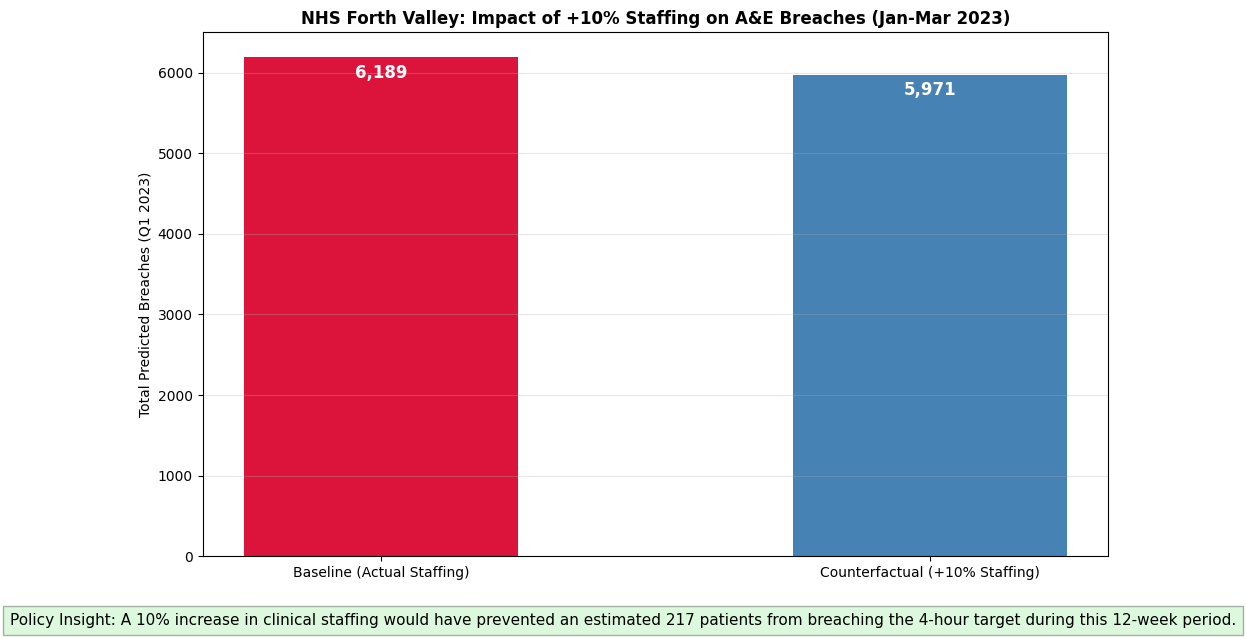

In [4]:
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(['Baseline (Actual Staffing)', 'Counterfactual (+10% Staffing)'], 
              [baseline_breaches, cf_breaches], 
              color=['crimson', 'steelblue'], width=0.5)

ax.set_ylabel('Total Predicted Breaches (Q1 2023)')
ax.set_title('NHS Forth Valley: Impact of +10% Staffing on A&E Breaches (Jan-Mar 2023)', fontweight='bold')

# Add text labels on top of the bars
for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval - (yval*0.05), 
            f'{int(yval):,}', ha='center', va='bottom', 
            color='white', fontweight='bold', fontsize=12)

# Add a text box highlighting the avoided breaches
plt.figtext(0.5, -0.05, f"Policy Insight: A 10% increase in clinical staffing would have prevented an estimated {int(breaches_avoided)} patients from breaching the 4-hour target during this 12-week period.", 
            ha="center", fontsize=11, bbox={"facecolor":"lightgreen", "alpha":0.3, "pad":5})

ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../data/processed/counterfactual_staffing.png', dpi=150, bbox_inches='tight')
plt.show()